# 식수 인원 예측 성능 향상 (V2)

`간단한_EDA.ipynb`를 참고하여, 사내 근무자수 파생 변수를 추가하고 메뉴 텍스트 파싱을 고도화한 노트북입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import korean_font
korean_font.set_korean_font()

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


## 1. 데이터 로드

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1205, 12)
Test shape: (50, 10)


## 2. 데이터 전처리
### 2.1 날짜 및 인원 파생 변수
`식사가능인원` = `본사정원수` - `본사휴가자수` - `본사출장자수` - `재택근무자수`
`야근비율` = `본사시간외근무명령서승인건수` / `식사가능인원`

In [4]:
def process_date(df):
    df['일자'] = pd.to_datetime(df['일자'])
    df['year'] = df['일자'].dt.year
    df['month'] = df['일자'].dt.month
    df['day'] = df['일자'].dt.day
    df['weekday'] = df['일자'].dt.weekday
    return df

train = process_date(train)
test = process_date(test)

def process_personnel(df):
    # 식사가능인원 (in_office)
    df['식사가능인원'] = df['본사정원수'] - df['본사휴가자수'] - df['본사출장자수'] - df['현본사소속재택근무자수']
    # 야근비율
    df['야근비율'] = df['본사시간외근무명령서승인건수'] / df['식사가능인원']
    return df

train = process_personnel(train)
test = process_personnel(test)

### 2.2 메뉴 파싱 및 피처 생성
원산지 정보 등을 제거하고 공백 기준으로 분리하여 처음 3개의 요소를 각각 `밥`, `국`, `메인반찬`으로 사용합니다.

In [5]:
def parse_menu(menu_series):
    bob = []
    soup = []
    main = []
    for menu_str in menu_series:
        items = menu_str.split()
        items = [x for x in items if '(' not in x and ')' not in x]
        b = items[0] if len(items) > 0 else '없음'
        s = items[1] if len(items) > 1 else '없음'
        m = items[2] if len(items) > 2 else '없음'
        bob.append(b)
        soup.append(s)
        main.append(m)
    return bob, soup, main

train['중식밥'], train['중식국'], train['중식메인'] = parse_menu(train['중식메뉴'])
train['석식밥'], train['석식국'], train['석식메인'] = parse_menu(train['석식메뉴'])
test['중식밥'], test['중식국'], test['중식메인'] = parse_menu(test['중식메뉴'])
test['석식밥'], test['석식국'], test['석식메인'] = parse_menu(test['석식메뉴'])

display(train[['중식메뉴', '중식밥', '중식국', '중식메인']].head(3))

,중식메뉴,중식밥,중식국,중식메인
0,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...",쌀밥/잡곡밥,오징어찌개,쇠불고기
1,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...",쌀밥/잡곡밥,김치찌개,가자미튀김
2,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...",카레덮밥,팽이장국,치킨핑거


### 2.3 범주형 변수 인코딩
`OrdinalEncoder`를 사용하되 학습 시 보지 못한 값이 나올 경우 대비하여 `handle_unknown='use_encoded_value'` 적용.

In [6]:
cat_features = ['요일', '중식밥', '중식국', '중식메인', '석식밥', '석식국', '석식메인']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[cat_features] = encoder.fit_transform(train[cat_features])
test[cat_features] = encoder.transform(test[cat_features])
display(train[cat_features].head(3))

,요일,중식밥,중식국,중식메인,석식밥,석식국,석식메인
0,3.0,49.0,188.0,235.0,68.0,226.0,344.0
1,4.0,49.0,26.0,6.0,115.0,183.0,339.0
2,2.0,67.0,250.0,333.0,68.0,248.0,433.0


## 3. 모델링 및 학습

In [8]:
features_lunch = ['weekday', 'year', 'month', 'day', '본사정원수', '본사휴가자수', '본사출장자수', '본사시간외근무명령서승인건수', '현본사소속재택근무자수', '식사가능인원', '야근비율', '중식밥', '중식국', '중식메인']
features_dinner = ['weekday', 'year', 'month', 'day', '본사정원수', '본사휴가자수', '본사출장자수', '본사시간외근무명령서승인건수', '현본사소속재택근무자수', '식사가능인원', '야근비율', '석식밥', '석식국', '석식메인']

X_lunch = train[features_lunch]
y_lunch = train['중식계']
X_dinner = train[features_dinner]
y_dinner = train['석식계']
test_lunch = test[features_lunch]
test_dinner = test[features_dinner]

In [9]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

def train_and_evaluate(X, y, test_X, feature_names, target_name):
    models = []
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_X))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
        model = LGBMRegressor(n_estimators=300, random_state=42, learning_rate=0.05)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='mae')
        
        val_pred = model.predict(X_va)
        oof_preds[val_idx] = val_pred
        test_preds += model.predict(test_X) / n_splits
        
        mae = mean_absolute_error(y_va, val_pred)
        print(f"Fold {fold+1} MAE: {mae:.4f}")
        models.append(model)
        
    print(f"Total OOF MAE for {target_name}: {mean_absolute_error(y, oof_preds):.4f}\n")
    return models, test_preds

print("--- 중식계 모델 학습 ---")
models_lunch, preds_lunch = train_and_evaluate(X_lunch, y_lunch, test_lunch, features_lunch, "중식계")

print("--- 석식계 모델 학습 ---")
models_dinner, preds_dinner = train_and_evaluate(X_dinner, y_dinner, test_dinner, features_dinner, "석식계")

--- 중식계 모델 학습 ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1743
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 14
[LightGBM] [Info] Start training from score 890.409751
Fold 1 MAE: 73.2491
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1742
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 14
[LightGBM] [Info] Start training from score 884.246888
Fold 2 MAE: 73.1820
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1747
[LightGBM] [Info] Number of data points in the train set: 964,

## 4. 평가 및 결과 저장
### 4.1 변수 중요도 (Feature Importance)

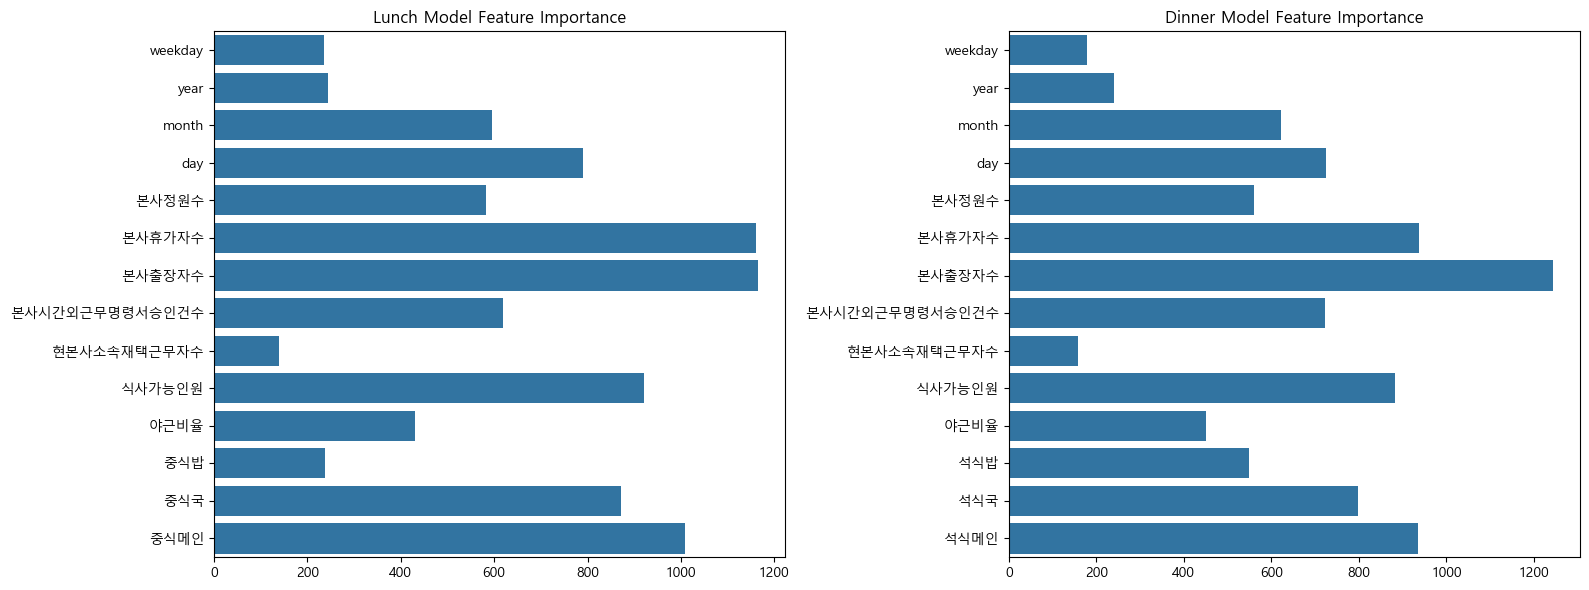

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
lgbm_lunch = models_lunch[0]
sns.barplot(x=lgbm_lunch.feature_importances_, y=features_lunch, ax=ax[0])
ax[0].set_title('Lunch Model Feature Importance')
lgbm_dinner = models_dinner[0]
sns.barplot(x=lgbm_dinner.feature_importances_, y=features_dinner, ax=ax[1])
ax[1].set_title('Dinner Model Feature Importance')
plt.tight_layout()
plt.show()

### 4.2 제출 파일 저장

In [11]:
submission['중식계'] = preds_lunch
submission['석식계'] = np.clip(preds_dinner, 0, None)
submission.to_csv('dining_submission_v2.csv', index=False)
display(submission.head())

,일자,중식계,석식계
0,2021-01-27,977.460013,249.442172
1,2021-01-28,937.730452,435.885167
2,2021-01-29,560.866911,252.202782
3,2021-02-01,1208.347014,506.794913
4,2021-02-02,1033.250852,432.150801
